# Project: SQL + Python for Data Analysis
## GreenCart — Online Grocery Delivery Analytics

You've just joined **GreenCart**, an online grocery delivery startup operating
across several Nigerian cities, as a junior data analyst. The operations team
wants to understand how the business is performing: which products and
customers drive revenue, how order fulfillment looks, and where customers are
being lost.

You've been given read access to the company's database (`greencart.db`) and
asked to produce an analysis with clear, actionable recommendations.

### What you'll practice
- Writing SQL queries (aggregation, joins, filtering, grouping, subqueries)
- Pulling SQL results into pandas for further analysis
- Feature engineering and segmentation with pandas/NumPy
- Data visualization
- Communicating findings to a non-technical audience

### Deliverable
A completed version of this notebook, with:
1. All SQL and Python cells filled in and run
2. Charts for each visualization task
3. A written summary of insights and recommendations (Part 3)

**Make sure `greencart.db` is in the same folder as this notebook before you start.**

---
## Database Schema

The database has 4 tables:

**`customers`**
| column | type | description |
|---|---|---|
| customer_id | INTEGER (PK) | unique customer identifier |
| name | TEXT | customer full name |
| email | TEXT | customer email |
| city | TEXT | customer's city |
| signup_date | TEXT (date) | date the customer created an account |
| segment | TEXT | `New`, `Regular`, or `Premium` |

**`products`**
| column | type | description |
|---|---|---|
| product_id | INTEGER (PK) | unique product identifier |
| product_name | TEXT | product name |
| category | TEXT | product category |
| unit_price | REAL | price per unit, in NGN |

**`orders`**
| column | type | description |
|---|---|---|
| order_id | INTEGER (PK) | unique order identifier |
| customer_id | INTEGER (FK → customers) | who placed the order |
| order_date | TEXT (date) | date the order was placed |
| status | TEXT | `Completed`, `Cancelled`, or `Pending` |

**`order_items`**
| column | type | description |
|---|---|---|
| order_item_id | INTEGER (PK) | unique line-item identifier |
| order_id | INTEGER (FK → orders) | which order this belongs to |
| product_id | INTEGER (FK → products) | which product was ordered |
| quantity | INTEGER | how many units were ordered |

**Relationships:** `customers` 1→N `orders` 1→N `order_items` N→1 `products`

> ⚠️ **Important business rule:** revenue should only be counted for orders
> with `status = 'Completed'`. `Cancelled` and `Pending` orders never
> generated revenue — several tasks below will trip you up if you forget this.

---
## Setup

Run this cell to connect to the database.

In [4]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

conn = sqlite3.connect("greencart.db")

# Quick check: list the tables
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)


,name
0,customers
1,products
2,orders
3,order_items


In [5]:
query = """
SELECT * FROM sqlite_master
"""
pd.read_sql_query(query, conn)

,type,name,tbl_name,rootpage,sql
0,table,customers,customers,2,CREATE TABLE customers (\n customer_id INTE...
1,table,products,products,3,CREATE TABLE products (\n product_id INTEGE...
2,table,orders,orders,4,CREATE TABLE orders (\n order_id INTEGER PR...
3,table,order_items,order_items,5,CREATE TABLE order_items (\n order_item_id ...


Throughout this project, run SQL queries like this:

```python
query = """
SELECT * FROM customers LIMIT 5;
"""
pd.read_sql_query(query, conn)
```

`pd.read_sql_query()` runs your SQL against the connection and returns the
result directly as a DataFrame — this is the pattern you'll use for every SQL
task below.

---
# Part 1: SQL Analysis

Write and run a SQL query for each task. Use joins, `GROUP BY`, `WHERE`, and
subqueries/CTEs where needed.

### 1.0 (Worked example)
How many rows are in each table? *(This one is done for you, to show the
expected format.)*

In [6]:
query = """
SELECT
    (SELECT COUNT(*) FROM customers)   AS num_customers,
    (SELECT COUNT(*) FROM products)     AS num_products,
    (SELECT COUNT(*) FROM orders)        AS num_orders,
    (SELECT COUNT(*) FROM order_items)    AS num_order_items;
"""
pd.read_sql_query(query, conn)


,num_customers,num_products,num_orders,num_order_items
0,180,38,971,3472


### 1.1
What is the **total revenue** from completed orders only? Revenue for a line
item is `quantity * unit_price`.

*(Hint: join `order_items` → `products` and `order_items` → `orders`, filter
by status.)*

In [7]:
query = """
-- YOUR SQL HERE
SELECT SUM(quantity * unit_price) AS total_revenue
FROM order_items AS oi
JOIN products AS p 
ON oi.product_id = p.product_id
JOIN orders AS o
ON oi.order_id = o.order_id
WHERE status = 'Completed'
ORDER BY status;
"""
pd.read_sql_query(query, conn)


,total_revenue
0,25563300.0


### 1.2
What are the **top 10 products by total revenue** (completed orders only)?
Show product name, category, and total revenue, sorted highest first.

In [8]:
query = """
-- YOUR SQL HERE
SELECT product_name, category, SUM(quantity * unit_price) AS total_revenue  
FROM products AS p
JOIN order_items AS oi
ON oi.product_id = p.product_id
JOIN orders AS o
ON oi.order_id = o.order_id
WHERE status = 'Completed'
GROUP BY product_name, category
ORDER BY total_revenue DESC LIMIT 10;
"""
pd.read_sql_query(query, conn)


,product_name,category,total_revenue
0,Beef (1kg),Meat & Seafood,2146750.0
1,Semovita (2kg),Grains & Pasta,1956400.0
2,Rice (5kg),Grains & Pasta,1942200.0
3,Fresh Fish (1kg),Meat & Seafood,1935750.0
4,Chicken (1kg),Meat & Seafood,1536000.0
5,Beans (2kg),Grains & Pasta,1524750.0
6,Garri (2kg),Grains & Pasta,1351350.0
7,Trash Bags (30ct),Household,1137600.0
8,Frozen Shrimp (500g),Meat & Seafood,1128000.0
9,Spaghetti (500g),Grains & Pasta,1037500.0


### 1.3
What is the **monthly revenue trend**? Show one row per month (e.g. `2024-01`)
with total revenue from completed orders, sorted chronologically.

*(Hint: SQLite's `strftime('%Y-%m', order_date)` extracts the year-month from
a date string.)*

In [9]:
query = """
-- YOUR SQL HERE
SELECT strftime('%Y-%m', order_date) AS month, SUM(unit_price * quantity) as total_revenue
FROM orders AS o
JOIN order_items AS oi
ON o.order_id = oi.order_id
JOIN products as p
ON p.product_id = oi.product_id
GROUP BY month
ORDER BY month ASC
limit 10;
"""
monthly_revenue = pd.read_sql_query(query, conn)
monthly_revenue


,month,total_revenue
0,2024-01,601650.0
1,2024-02,762850.0
2,2024-03,406400.0
3,2024-04,889950.0
4,2024-05,889850.0
5,2024-06,1303100.0
6,2024-07,894450.0
7,2024-08,876950.0
8,2024-09,832200.0
9,2024-10,1077100.0


### 1.4
What is the **average order value** (completed orders only) broken down by
customer `segment` (New / Regular / Premium)?

In [10]:
query = """
-- YOUR SQL HERE
WITH order_total AS (
    SELECT 
        o.order_id, 
        o.customer_id, 
        SUM(oi.quantity * p.unit_price) AS order_value
    FROM orders AS o 
    JOIN order_items AS oi 
    ON o.order_id = oi.order_id
    JOIN products AS p 
    ON oi.product_id = p.product_id   --  this was missing
    WHERE o.status = 'Completed'
    GROUP BY o.order_id, o.customer_id
)
SELECT 
    c.segment, 
    AVG(ot.order_value) AS avg_order_value
FROM order_total AS ot
JOIN customers AS c 
ON ot.customer_id = c.customer_id
GROUP BY c.segment;
"""
pd.read_sql_query(query, conn)


,segment,avg_order_value
0,New,29447.857143
1,Premium,30258.217270
2,Regular,32491.645244


### 1.5
List the **top 10 customers by total spend** (completed orders only). Show
customer name, city, segment, and total spend.

In [11]:
query = """
-- YOUR SQL HERE
SELECT 
    name,
    city,
    segment, 
    SUM(quantity * unit_price) as total_spend
FROM products AS p 
JOIN order_items AS oi 
ON p.product_id = oi.product_id
JOIN orders AS o 
ON oi.order_id = o.order_id
JOIN customers AS c
ON c.customer_id = o.customer_id
WHERE status = "Completed"
GROUP BY name,city,segment
ORDER BY total_spend DESC
lIMIT 10
"""
pd.read_sql_query(query, conn)


,name,city,segment,total_spend
0,Efe Hassan,Lagos,Premium,691350.0
1,Blessing Wahab,Lagos,Premium,605900.0
2,Dele Raji,Abuja,Premium,548850.0
3,Yemi Wahab,Kano,Premium,543850.0
4,Chukwu Balogun,Ibadan,Premium,523550.0
5,Amina Okafor,Abuja,Premium,501600.0
6,Gift Quadri,Enugu,Premium,469050.0
7,Ibrahim Chinwe,Enugu,Premium,466550.0
8,Halima Balogun,Lagos,Premium,452350.0
9,Ngozi Udo,Lagos,Premium,438350.0


### 1.6
What **percentage of all orders** fall into each status (`Completed`,
`Cancelled`, `Pending`)? This matters operationally — a high cancellation
rate is a red flag worth investigating.

In [12]:
query = """
-- YOUR SQL HERE
    SELECT status,
    COUNT(*) AS order_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*)
FROM orders), 2) AS percentage
FROM orders 
GROUP BY status
ORDER BY percentage DESC;
"""
pd.read_sql_query(query, conn)


,status,order_count,percentage
0,Completed,818,84.24
1,Cancelled,104,10.71
2,Pending,49,5.05


### 1.7 — Onboarding drop-off
Find every customer who **signed up but has never placed a single order**
(of any status). Show their name, city, and signup date.

*(Hint: this needs a `LEFT JOIN` from `customers` to `orders`, then filtering
for where the order side is missing.)*

In [13]:
query = """
-- YOUR SQL HERE
    SELECT  name, city, signup_date
FROM customers AS c
LEFT JOIN orders AS o
ON c.customer_id = o.customer_id
WHERE o.customer_id IS NULL
"""
never_ordered = pd.read_sql_query(query, conn)
print(f"{len(never_ordered)} customers have never placed an order.")
never_ordered


30 customers have never placed an order.


,name,city,signup_date
0,Ifeoma Kalu,Lagos,2023-12-30
1,Wale Vincent,Ibadan,2024-07-24
2,Femi Quadri,Abuja,2024-07-05
3,Kelechi Popoola,Lagos,2023-09-15
4,Gift Hassan,Port Harcourt,2025-02-26
5,Yusuf Jibril,Abuja,2023-04-25
6,Obi Dauda,Lagos,2023-01-01
7,Kunle Garba,Enugu,2023-03-01
8,Precious Yakubu,Lagos,2025-01-17
9,Chioma Fashola,Lagos,2024-12-31


### 1.8
Which **city** has the highest average order value (completed orders only)?
Show all cities, sorted from highest to lowest average order value.

In [14]:
query = """
-- YOUR SQL HERE
SELECT city, SUM(quantity * unit_price)/ count(DISTINCT o.order_id) AS Avg_order_value
FROM customers AS C
JOIN orders AS o 
ON c.customer_id = o.customer_id
JOIN order_items AS oi
ON oi.order_id = o.order_id
JOIN products as p 
ON p.product_id = oi.product_id
WHERE status = "Completed"
GROUP BY city
ORDER BY Avg_order_value DESC
"""
pd.read_sql_query(query, conn)


,city,Avg_order_value
0,Benin City,35481.250000
1,Port Harcourt,35148.837209
2,Enugu,32675.342466
3,Abuja,31200.763359
4,Lagos,30666.610738
5,Ibadan,28458.888889
6,Kano,28345.238095


### 1.9 (Bonus — CTE / subquery)
For each customer who has placed at least one completed order, find their
**most recent completed order date**. Then flag any customer whose most
recent order was **more than 90 days before the latest order date in the
whole dataset** — these are your at-risk / inactive customers.

*(Hint: you can do this with a Common Table Expression (`WITH ... AS (...)`)
that computes each customer's last order date, compared against
`(SELECT MAX(order_date) FROM orders)`.)*

In [15]:
query = """
-- YOUR SQL HERE (bonus)


WITH customerlastorder AS (
SELECT 
    customer_Id,
    Max(order_date) as most_recent_order_date
FROM orders
WHERE status = "Completed"
GROUP BY customer_id
)
SELECT 
    customer_id,
    most_recent_order_date,
CASE
    WHEN julianday((SELECT Max(order_date) FROM orders) - julianday(most_recent_order_date)) > 90
    THEN "At risk / Inactive"
    ELSE "Active"
END AS customer_status 
FROM customerlastorder
"""
pd.read_sql_query(query, conn)


,customer_Id,most_recent_order_date,customer_status
0,1,2025-06-17,Active
1,2,2025-04-21,Active
2,3,2025-06-28,Active
3,4,2025-08-22,Active
4,5,2025-08-22,Active
...,...,...,...
143,176,2025-08-12,Active
144,177,2024-07-15,Active
145,178,2025-08-22,Active
146,179,2025-06-01,Active


---
# Part 2: Python Analysis

Now go beyond what SQL alone conveniently gives you — pull raw tables into
pandas and build a fuller picture.

### 2.0 Setup — pull the raw tables into pandas
Run this cell to load all four tables as DataFrames. You'll use these for the
rest of Part 2.

In [16]:
customers_df = pd.read_sql_query("SELECT * FROM customers;", conn)
products_df = pd.read_sql_query("SELECT * FROM products;", conn)
orders_df = pd.read_sql_query("SELECT * FROM orders;", conn)
order_items_df = pd.read_sql_query("SELECT * FROM order_items;", conn)

# Convert date columns to actual datetime objects
customers_df["signup_date"] = pd.to_datetime(customers_df["signup_date"])
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])

print(customers_df.shape, products_df.shape, orders_df.shape, order_items_df.shape)
customers_df.head()


(180, 6) (38, 4) (971, 4) (3472, 4)


,customer_id,name,email,city,signup_date,segment
0,1,Dele Raji,dele.raji1@example.com,Abuja,2023-07-16,Premium
1,2,David Balogun,david.balogun2@example.com,Port Harcourt,2023-02-16,Regular
2,3,Zara Garba,zara.garba3@example.com,Lagos,2025-03-02,New
3,4,Halima Balogun,halima.balogun4@example.com,Lagos,2025-05-25,Premium
4,5,Amina Bello,amina.bello5@example.com,Ibadan,2023-04-14,Regular


### 2.1 Build one master table
Merge `order_items_df`, `orders_df`, `products_df`, and `customers_df` into a
single DataFrame called `full_df`, where each row is one line item, with all
the customer/product/order context attached. Add a `revenue` column
(`quantity * unit_price`).

Then filter `full_df` down to `completed_df` — only rows where
`status == "Completed"` — since that's what you'll use for revenue analysis
going forward.

In [17]:
# YOUR CODE HERE
full_df =  (order_items_df
        .merge(orders_df, on="order_id")
        .merge(customers_df, on="customer_id")
        .merge(products_df, on="product_id")
)
full_df["revenue"] = full_df["quantity"] * full_df["unit_price"]

completed_df = full_df[full_df["status"] == "Completed"]
completed_df.head()


,order_item_id,order_id,product_id,quantity,customer_id,order_date,status,name,email,city,signup_date,segment,product_name,category,unit_price,revenue
0,1,1,33,2,1,2024-11-17,Completed,Dele Raji,dele.raji1@example.com,Abuja,2023-07-16,Premium,Frozen Shrimp (500g),Meat & Seafood,6000.0,12000.0
1,2,1,8,3,1,2024-11-17,Completed,Dele Raji,dele.raji1@example.com,Abuja,2023-07-16,Premium,Fresh Milk (1L),Dairy & Eggs,1100.0,3300.0
2,3,1,25,1,1,2024-11-17,Completed,Dele Raji,dele.raji1@example.com,Abuja,2023-07-16,Premium,Chin Chin (400g),Snacks,1750.0,1750.0
3,4,1,37,4,1,2024-11-17,Completed,Dele Raji,dele.raji1@example.com,Abuja,2023-07-16,Premium,Semovita (2kg),Grains & Pasta,7300.0,29200.0
4,5,2,35,3,1,2024-01-02,Completed,Dele Raji,dele.raji1@example.com,Abuja,2023-07-16,Premium,Spaghetti (500g),Grains & Pasta,4150.0,12450.0


### 2.2 Visualize the monthly revenue trend
Using `completed_df`, group revenue by year-month and plot it as a line
chart. Compare your total against your SQL answer from Task 1.3 — they
should match!

*(Hint: `completed_df["order_date"].dt.to_period("M")` gives you a year-month
grouping key.)*

C:\Users\Hp\AppData\Local\Temp\ipykernel_12188\2588328857.py:4: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'M' instead.
  completed_df["year_month"] = completed_df["order_date"].dt.to_period("m")


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='year_month'>

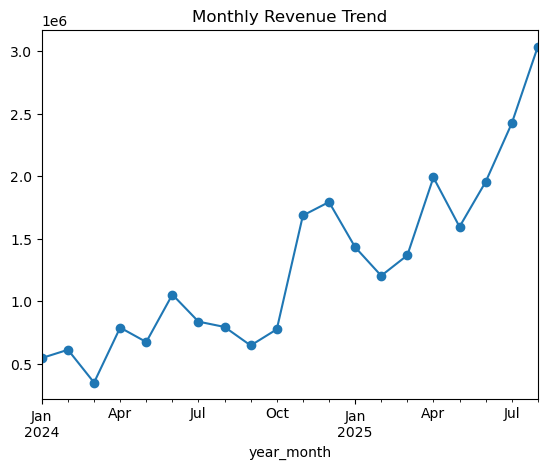

In [18]:
# YOUR CODE HERE
completed_df = completed_df.copy()

completed_df["year_month"] = completed_df["order_date"].dt.to_period("m")

monthly_revenue = completed_df.groupby("year_month")["revenue"].sum()

monthly_revenue.plot(kind="line", marker=("o"), title="Monthly Revenue Trend")


### 2.3 Visualize revenue by category
Group `completed_df` by `category` and plot total revenue as a horizontal bar
chart, sorted from highest to lowest.

Text(0.5, 1.0, 'Category by total revenue')

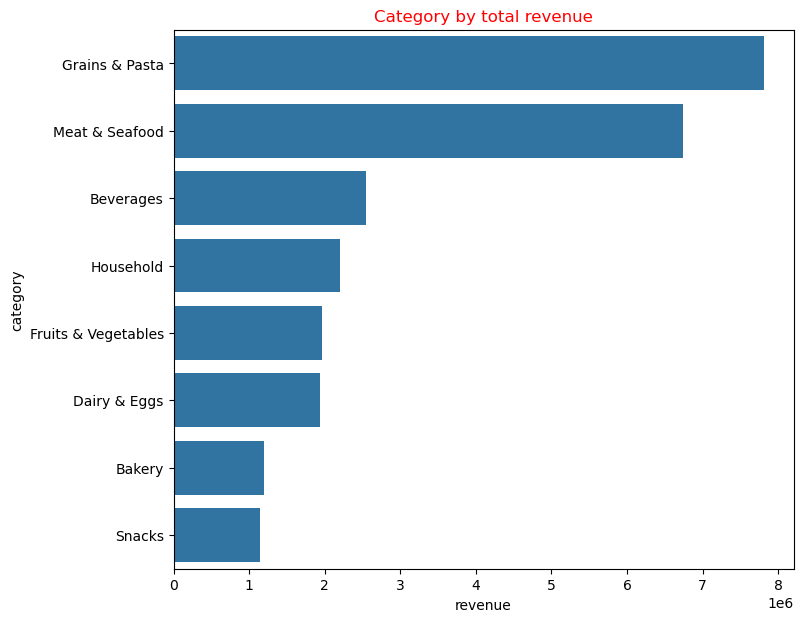

In [19]:
# YOUR CODE HERE
by_category = completed_df.groupby("category")["revenue"].sum().reset_index()
by_category = by_category.sort_values(by="revenue", ascending=False)

plt.figure(figsize=(8,7))
sb.barplot(data=by_category, y="category", x="revenue")
plt.title("Category by total revenue", color="red")

### 2.4 Customer-level summary table
Build a DataFrame called `customer_summary`, grouped by customer, with one
row per customer who has placed at least one completed order, containing:
- `total_spend` — sum of revenue
- `num_orders` — number of *distinct* completed orders
- `avg_order_value` — total_spend / num_orders
- `last_order_date` — most recent completed order date

*(Hint: `.groupby("customer_id").agg(...)` with a dictionary, or named
aggregation with `.agg(total_spend=("revenue","sum"), ...)`. You'll need
`order_id.nunique()` for a correct order count, since each order has
multiple line items.)*

In [20]:
# YOUR CODE HERE
customer_summary = completed_df.groupby("customer_id").agg(
    total_spend = ("revenue","sum"),
    num_orders = ("order_id", "nunique"),
    last_order_date = ("order_date", "max")
).reset_index()

customer_summary["avg_order_value"] = customer_summary["total_spend"] / customer_summary["num_orders"]

customer_summary.head()


,customer_id,total_spend,num_orders,last_order_date,avg_order_value
0,1,548850.0,14,2025-06-17,39203.571429
1,2,331600.0,8,2025-04-21,41450.000000
2,3,40250.0,1,2025-06-28,40250.000000
3,4,452350.0,16,2025-08-22,28271.875000
4,5,160800.0,4,2025-08-22,40200.000000


### 2.5 Recompute the at-risk customers (cross-check with SQL)
Using `customer_summary`, find customers whose `last_order_date` is more than
90 days before the maximum `last_order_date` in the table. Store the result
in `at_risk_customers`. Compare the count to your SQL answer from Task 1.9 —
they should match (allowing for the fact that customers with **zero** orders
won't appear in `customer_summary` at all, since it's built only from
completed orders).

In [21]:
# YOUR CODE HERE
customer_summary["last_order_date"] = pd.to_datetime(customer_summary["last_order_date"])
max_date =  customer_summary["last_order_date"].max()

at_risk_customers = customer_summary[customer_summary["last_order_date"] < max_date - pd.Timedelta(days=90)]

print(f"{len(at_risk_customers)} at-risk customers found.")
at_risk_customers.sort_values("last_order_date").head()


56 at-risk customers found.


,customer_id,total_spend,num_orders,last_order_date,avg_order_value
107,130,36700.0,1,2024-01-14,36700.000000
11,13,7050.0,1,2024-01-27,7050.000000
59,72,16700.0,1,2024-03-29,16700.000000
16,19,8200.0,1,2024-04-03,8200.000000
127,154,160600.0,3,2024-06-09,53533.333333


### 2.6 Spend tiers
Using `pd.qcut()` or `pd.cut()`, split customers in `customer_summary` into
three spend tiers — `"Low"`, `"Medium"`, `"High"` — based on `total_spend`.
Store this as a new column `spend_tier`. Then plot a bar chart showing how
many customers fall into each tier.

In [22]:
# YOUR CODE HERE
customer_summary["spend_tier"] = pd.qcut(customer_summary["total_spend"],
    q=3,
    labels = ["Low","Medium","High"]
)
customer_summary["spend_tier"]

0        High
1        High
2         Low
3        High
4      Medium
        ...  
143    Medium
144       Low
145    Medium
146    Medium
147    Medium
Name: spend_tier, Length: 148, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

### 2.7 (Bonus) Simple RFM segmentation
RFM stands for **Recency, Frequency, Monetary** — a classic customer
segmentation technique:
- **Recency**: how recently did they order? (fewer days since last order = better)
- **Frequency**: how many orders have they placed? (more = better)
- **Monetary**: how much have they spent in total? (more = better)

Using `customer_summary`:
1. Compute `recency_days` — days between each customer's `last_order_date`
   and the max `last_order_date` in the dataset.
2. Use `pd.qcut()` to score each of Recency, Frequency, and Monetary into
   quartiles (1–4, where 4 is "best" — careful, for Recency a **smaller**
   number of days is better, so you'll need to reverse that scoring).
3. Combine the three scores into an `rfm_score` (e.g., sum or concatenate them).
4. Show the top 10 customers by `rfm_score`.

In [145]:
# YOUR CODE HERE (bonus)

# 1. Score Recency into quartiles (reversed because fewer days = better)
max_date = pd.to_datetime(customer_summary["last_order_date"]).max()
customer_summary["recency_days"] = (max_date - pd.to_datetime(customer_summary["last_order_date"])).dt.days

# 2
customer_summary["recency_score"] = pd.cut(
    customer_summary["recency_days"], 
    bins=4, 
    labels=[4, 3, 2, 1]
).astype(int)

# 3. Score Frequency into quartiles (more orders = better)
customer_summary["frequency_score"] = pd.cut(
    customer_summary["num_orders"], 
    bins=4, 
    labels=[1, 2, 3, 4]
).astype(int)

# 4. Score Monetary into quartiles (more spend = better)
customer_summary["monetary_score"] = pd.cut(
    customer_summary["total_spend"], 
    bins=4, 
    labels=[1, 2, 3, 4]
).astype(int)

# 5. Combine scores into an rfm_score (summing them)
customer_summary["rfm_score"] = (
    customer_summary["recency_score"] + 
    customer_summary["frequency_score"] + 
    customer_summary["monetary_score"]
)

# 6. Show the top 10 customers by rfm_score
top_10_rfm = customer_summary.sort_values(by="rfm_score", ascending=False).head(10)
display(top_10_rfm)


,customer_id,total_spend,num_orders,last_order_date,avg_order_value,spend_tier,recency_days,recency_score,frequency_score,monetary_score,rfm_score
112,136,543850.0,19,2025-08-01,28623.684211,High,30,4,4,4,12
32,37,605900.0,17,2025-08-31,35641.176471,High,0,4,4,4,12
91,110,523550.0,15,2025-08-29,34903.333333,High,2,4,4,4,12
5,6,691350.0,19,2025-08-27,36386.842105,High,4,4,4,4,12
23,27,466550.0,16,2025-08-13,29159.375000,High,18,4,4,3,11
48,57,469050.0,15,2025-08-26,31270.000000,High,5,4,4,3,11
58,70,501600.0,15,2025-07-04,33440.000000,High,58,4,4,3,11
0,1,548850.0,14,2025-06-17,39203.571429,High,75,4,3,4,11
3,4,452350.0,16,2025-08-22,28271.875000,High,9,4,4,3,11
108,131,363900.0,14,2025-07-30,25992.857143,High,32,4,3,3,10


---
# Part 3: Business Insights & Recommendations

Write your findings below in plain language, as if presenting to GreenCart's
operations manager (who has no SQL/Python background). Reference specific
numbers from your analysis above.

Answer at least the following:

1. **Revenue trend** — Is revenue growing, flat, or declining over time? Any
   noticeable seasonal patterns?
2. **Product strategy** — Which categories or products should GreenCart
   promote more? Any that are underperforming?
3. **Customer retention** — How big is the at-risk/inactive customer group,
   and what would you recommend GreenCart do about it?
4. **Onboarding** — What does the "signed up but never ordered" group suggest
   about the signup experience?
5. **Geography** — Does city meaningfully affect order value? Would you
   recommend different strategies by city?
6. **One headline recommendation** — If GreenCart's manager could only act on
   one thing from your analysis, what should it be, and why?

> **Your write-up:**
>
> *(Replace this with your analysis — aim for a few sentences per question above.)*
>
> Revenue trend: Promote top-performing categories like Grains & Pasta. we see consistent growth, and focusing on top performers like Grains & Pasta ensures we capitalize on proven demand.
> Product strategy: Adjust product strategy by bundling underperforming items like Snacks with popular ones to boost sales. To enhance our product strategy, again, bundling underperforming categories like Snacks with popular items will increase sales volume across the board.
>
> Customer retention: implement targeted win-back campaigns for the fifty-six at-risk customers. Targeted campaigns directly addresses the fifty-six at-risk customers to win them back.  
>
> Onboarding: Address onboarding drop-offs by using automated campaigns with incentives for new sign-ups. Automated messaging with incentives will effectively convert new sign-ups who haven't placed an order yet.
>
> Geography: Customize promotional strategies to match consumer preferences by city. tailoring promotions to specific city preferences ensures our marketing resonates locally.
>
> One headline recommendation: I will recommend prioritize optimizing the onboarding process as headline recommendation to drive revenue.

---
## Submission checklist

- [ ] All SQL query cells in Part 1 are filled in and run without error
- [ ] All Python cells in Part 2 are filled in and run without error
- [ ] Every visualization task has a labeled chart (title + axis labels)
- [ ] Part 3 write-up references specific numbers from your analysis
- [ ] Notebook runs top-to-bottom without errors (Kernel → Restart & Run All)

## Grading rubric (suggested)

| Area | Weight | What's assessed |
|---|---|---|
| SQL correctness | 35% | Queries return correct, well-filtered results (watch the `Completed`-only rule!) |
| Python analysis | 30% | Correct merges/aggregations, sensible feature engineering |
| Visualizations | 15% | Clear, correctly labeled charts that support the analysis |
| Business insights | 20% | Clear, specific, numbers-backed recommendations — not generic statements |

Bonus tasks (1.9 and 2.7) are optional extra credit.